In [39]:
import os
import sys
sys.path.append(os.path.abspath(os.path.join("../")))

In [40]:
import numpy as np
import matplotlib.pyplot as plt
from src.parameters import Parameters
from src.acquisition import Acquisition
from src.forward import forward
from src.utilities import ricker_wavelet
from src.kernels import green2d
from src.plot.plot_tools import plot_seismogram

In [41]:
'''layers = [
        (500.0, 1500.0, 2000.0), # top layer
        (2000.0, 4500.0, 2000.0),
        (3000.0, 3000.0, 2000.0),
        (2500.0, 3800.0, 2000.0)
    ]'''

'layers = [\n        (500.0, 1500.0, 2000.0), # top layer\n        (2000.0, 4500.0, 2000.0),\n        (3000.0, 3000.0, 2000.0),\n        (2500.0, 3800.0, 2000.0)\n    ]'

In [42]:
# example from TOYxDAC_TIME
layers = [
        (100.0, 1505.0, 2000.0), # top layer
        (200.0, 1603.0, 2000.0),
        (250.0, 1749.0, 2000.0),
        (350.0, 2019.0, 2000.0),
        (450.0, 2179.0, 2000.0),
        (550.0, 1900.0, 2000.0),
        (650.0, 2265.0, 2000.0),
        (700.0, 3281.0, 2000.0),
    ]

In [43]:
total_time = 2.    # seconds
f0 = 8.0           # Ricker central frequency (Hz)
f_max = 8.0 * f0    # practical Ricker cutoff
# Nyquist frequency for f_max
dt = 1/(2.*f_max)
print("dt =", dt)
#dt = total_time / (nt-1)
nfft = 2**int(np.ceil(np.log2(total_time/dt)))
nfft *= 8 # zero-padding to ensure late wrap-around
print("nfft =", nfft)
nt = int(total_time / dt) + 1
print("nt =", nt)
#time = np.arange(nt) * dt

param = Parameters(total_time=total_time, nt=nt, f0=f0, nfft=nfft, epsilon=1.0) 

# x and z positions of sources
sources = [(10.0, 76.0)]
# x and z positions of receivers
Nr = 256
x_receivers = np.linspace(0.0, 3000.0, Nr) # offsets
receivers = [(x, 76.0) for x in x_receivers]
print(receivers)
acq = Acquisition(sources, receivers)

dt = 0.0078125
nfft = 2048
nt = 257
[(np.float64(0.0), 76.0), (np.float64(11.764705882352942), 76.0), (np.float64(23.529411764705884), 76.0), (np.float64(35.294117647058826), 76.0), (np.float64(47.05882352941177), 76.0), (np.float64(58.82352941176471), 76.0), (np.float64(70.58823529411765), 76.0), (np.float64(82.3529411764706), 76.0), (np.float64(94.11764705882354), 76.0), (np.float64(105.88235294117648), 76.0), (np.float64(117.64705882352942), 76.0), (np.float64(129.41176470588238), 76.0), (np.float64(141.1764705882353), 76.0), (np.float64(152.94117647058823), 76.0), (np.float64(164.7058823529412), 76.0), (np.float64(176.47058823529414), 76.0), (np.float64(188.23529411764707), 76.0), (np.float64(200.0), 76.0), (np.float64(211.76470588235296), 76.0), (np.float64(223.5294117647059), 76.0), (np.float64(235.29411764705884), 76.0), (np.float64(247.05882352941177), 76.0), (np.float64(258.82352941176475), 76.0), (np.float64(270.5882352941177), 76.0), (np.float64(282.3529411764706), 76.0), (n

elapsed: 4.11 s
Fortran reflectivity elapsed time: 0.36 s


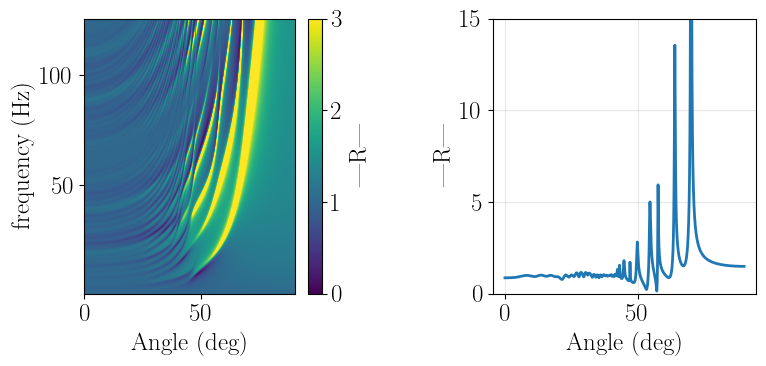

In [44]:
from src.reflectivity_kx_omega import reflectivity
from src.fortran.reflectivity_benchmark import fortran_reflectivity
import time
thetas = np.linspace(0., np.pi/2., 6*(1024-1))
omegas = 2*np.pi * np.linspace(0.1, 20, 1024) + 1.0*1j
Rmap = reflectivity(layers, omegas + 0.1*1j, thetas, 76., 76., mode="k0",  use_numba=True, fs=True) 
p = np.sin(thetas) / layers[0][1]
start = time.time()
R_f = fortran_reflectivity(layers, omegas, p, free_surface=1, zr=76., zs=76.)
end = time.time()
print(f"Fortran reflectivity elapsed time: {end-start:.2f} s")

fixed_omega = 80.
omega_idx = np.argmin(np.abs(omegas - fixed_omega))
R_at_omega = np.abs(R_f[omega_idx, :])

plt.figure(figsize=(8,4))
plt.subplot(1,2,1)
plt.imshow(np.abs(R_f), origin='lower',
            extent=[180.*thetas[0]/np.pi, 180.*thetas[-1]/np.pi, np.real(omegas[0]), np.real(omegas[-1])],
            aspect='auto',
            vmin=0, vmax=3.0)
plt.xlabel('Angle (deg)')
plt.ylabel('frequency (Hz)')
plt.colorbar(label='|R|')

plt.subplot(1,2,2)

plt.plot(180.*thetas/np.pi, R_at_omega, linewidth=2)

plt.xlabel('Angle (deg)')
plt.ylabel('|R|')
plt.grid(True, alpha=0.3)
plt.ylim([0, 15.0])
plt.tight_layout()
plt.show()

In [45]:
import numba
print("numba is using ", numba.get_num_threads() , " threads")

numba is using  22  threads


In [46]:
d_cal = forward(layers, acq, param, nq_prop=1024, free_surface=True, timing=True)

Sommerfeld quadrature elapsed: 5.67 s


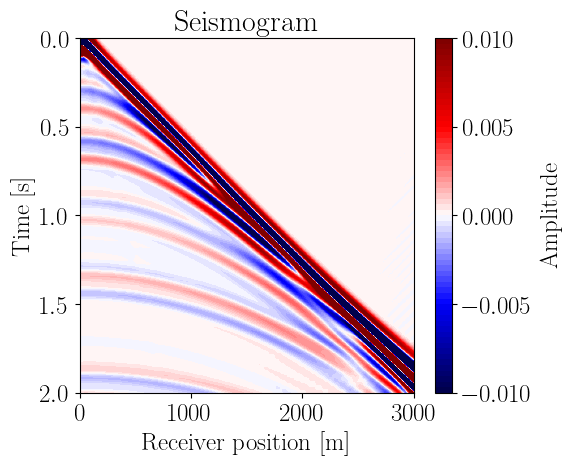

In [50]:
d_cal_seis = d_cal[0, :, :]
plot_seismogram(d_cal_seis.T, acq.xr, param.time, vmin=-0.01, vmax=0.01, cmap='seismic', ncolors=64, figsize=(6, 5))